In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
class DataLoader:
    def __init__(self, filepath='data.csv'):
        self.filepath = filepath

    def load_data(self):
        try:
            df = pd.read_csv(self.filepath)
            if 'x' in df.columns and 'y' in df.columns:
                return df[['x', 'y']]
            else:
                return df.iloc[:, [1, 2]] 
        except FileNotFoundError:
            print(f"File '{self.filepath}' not found. Using fallback sample data.")
            return pd.DataFrame(self.fallback_data, columns=['x', 'y'])

In [3]:
class KMeansClustering:
    def __init__(self, data, k=3, tol=1e-4, seed=42):
        self.data = data.copy()
        self.k = k
        self.tol = tol
        np.random.seed(seed)
        
        self.centroids = self._initiate_centroids()
        self.total_error = 0
        self.customcmap = ListedColormap(["crimson", "mediumblue", "darkmagenta"])

    def _initiate_centroids(self):
        return self.data.sample(self.k)

    def _distance(self, a, b):
        return np.sum(np.square(a - b))

    def _centroid_assignation(self, current_centroids):
        n = self.data.shape[0]
        assignation = []
        assign_errors = []

        for obs in range(n):
            all_errors = np.array([])
            for c in range(self.k):
                err = self._distance(current_centroids.iloc[c, :], self.data.iloc[obs, :])
                all_errors = np.append(all_errors, err)

            nearest_centroid = np.where(all_errors == np.amin(all_errors))[0].tolist()[0]
            nearest_centroid_error = np.amin(all_errors)

            assignation.append(nearest_centroid)
            assign_errors.append(nearest_centroid_error)

        return assignation, assign_errors

    def fit(self):
        goahead = True
        j = 0
        err_history = []
        
        while goahead:
            self.data['centroid'], j_err = self._centroid_assignation(self.centroids)
            err_history.append(sum(j_err))

            self.centroids = self.data.groupby('centroid')[['x', 'y']].agg('mean').reset_index(drop=True)

            if j > 0:
                if err_history[j-1] - err_history[j] <= self.tol:
                    goahead = False
            j += 1

        self.data['centroid'], j_err = self._centroid_assignation(self.centroids)
        self.centroids = self.data.groupby('centroid')[['x', 'y']].agg('mean').reset_index(drop=True)
        self.total_error = sum(j_err)

        return self.data['centroid'], self.total_error, self.centroids

    def plot_clusters(self, title="Clustering Result"):
        fig, ax = plt.subplots(figsize=(8, 6))
        
        plt.scatter(self.data['x'], self.data['y'], marker='o',
                    c=self.data['centroid'].astype('category'),
                    cmap=self.customcmap, s=80, alpha=0.5)
        
        plt.scatter(self.centroids['x'], self.centroids['y'],
                    marker='s', s=200, c=range(self.k),
                    cmap=self.customcmap)
        
        ax.set_xlabel('x', fontsize=14)
        ax.set_ylabel('y', fontsize=14)
        plt.title(title, fontsize=16)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.show()

In [4]:
class KMediansClustering(KMeansClustering):
    def _distance(self, a, b):
        return np.sum(np.abs(a - b))

    def fit(self):
        goahead = True
        j = 0
        err_history = []
        
        while goahead:
            self.data['centroid'], j_err = self._centroid_assignation(self.centroids)
            err_history.append(sum(j_err))

            self.centroids = self.data.groupby('centroid')[['x', 'y']].agg('median').reset_index(drop=True)

            if j > 0:
                if err_history[j-1] - err_history[j] <= self.tol:
                    goahead = False
            j += 1

        self.data['centroid'], j_err = self._centroid_assignation(self.centroids)
        self.centroids = self.data.groupby('centroid')[['x', 'y']].agg('median').reset_index(drop=True)
        self.total_error = sum(j_err)

        return self.data['centroid'], self.total_error, self.centroids

In [5]:
def plot_elbow_method(df, is_kmedians=False):
    err_total = []
    n_clusters_range = range(1, 11)
    
    for i in n_clusters_range:
        if is_kmedians:
            model = KMediansClustering(df, k=i)
        else:
            model = KMeansClustering(df, k=i)
            
        _, err, _ = model.fit()
        err_total.append(err)

    fig, ax = plt.subplots(figsize=(8, 6))
    plt.plot(n_clusters_range, err_total, linewidth=3, marker='o')
    
    method_name = "K-Medians" if is_kmedians else "K-Means"
    ax.set_xlabel('Number of clusters', fontsize=14)
    ax.set_ylabel('Total error', fontsize=14)
    plt.title(f'Elbow Method for {method_name}', fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

In [6]:
def Part1(df):
    print("# Part 1: K-Means Clustering")
    kmeans_model = KMeansClustering(df, k=3)
    assignments, total_error, final_centroids = kmeans_model.fit()
    
    print(f"Total error (Sum of Squared Errors): {total_error:.2f}")
    print("\nFinal Centroids (Mean):")
    print(final_centroids)
    
    print("\nPlotting K-Means Clusters...")
    kmeans_model.plot_clusters(title="K-Means Clustering Result")
    
    print("\nPlotting Elbow Curve for K-Means...")
    plot_elbow_method(df, is_kmedians=False)
    print("\n" + "="*50 + "\n")

In [7]:
def Part2(df):
    print("# Part 2: K-Medians Clustering")
    kmedians_model = KMediansClustering(df, k=3)
    assignments, total_error, final_centroids = kmedians_model.fit()
    
    print(f"Total error (Sum of Manhattan Distances): {total_error:.2f}")
    print("\nFinal Centroids (Median):")
    print(final_centroids)
    
    print("\nPlotting K-Medians Clusters...")
    kmedians_model.plot_clusters(title="K-Medians Clustering Result")
    
    print("\nPlotting Elbow Curve for K-Medians...")
    plot_elbow_method(df, is_kmedians=True)
    print("\n" + "="*50 + "\n")

# Part 1: K-Means Clustering
Total error (Sum of Squared Errors): 2698.39

Final Centroids (Mean):
           x          y
0  29.330864  10.432409
1  29.527364  39.328909
2   6.322867  19.559800

Plotting K-Means Clusters...


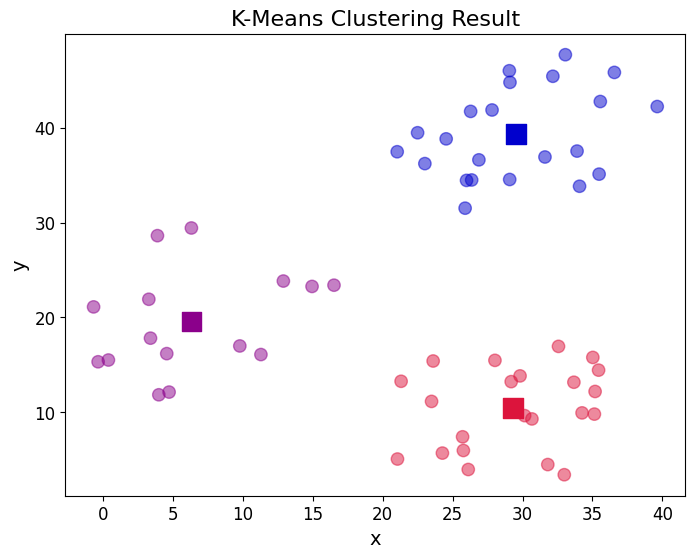


Plotting Elbow Curve for K-Means...


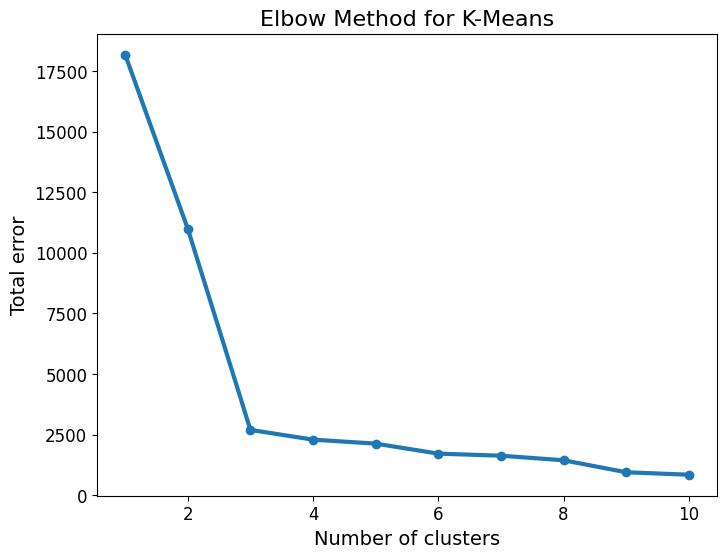



# Part 2: K-Medians Clustering
Total error (Sum of Manhattan Distances): 477.64

Final Centroids (Median):
         x        y
0  29.9860  10.5365
1  29.0685  38.1785
2   4.5500  17.8100

Plotting K-Medians Clusters...


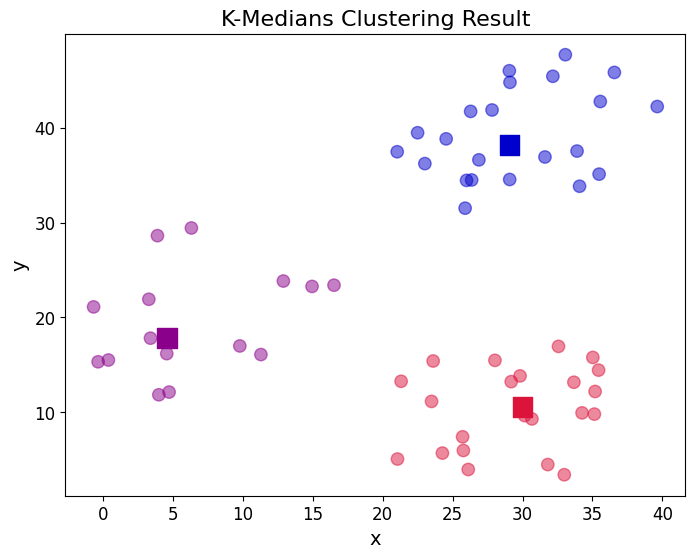


Plotting Elbow Curve for K-Medians...


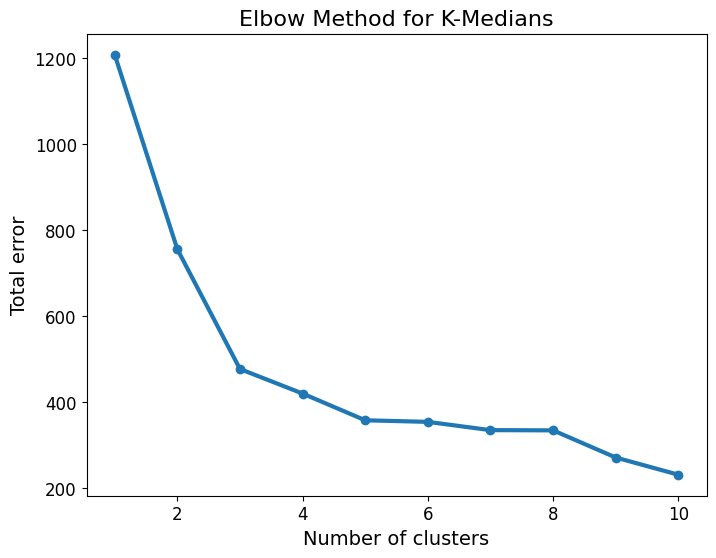

In [8]:
if __name__ == "__main__":
    loader = DataLoader('data.csv')
    df = loader.load_data()
    
    Part1(df)
    Part2(df)